# Fungi-tastic EDA

### Import packages and load data

In [25]:
%reload_ext autoreload
%autoreload 2
%aimport -numpy, -pandas, -matplotlib

import sys
import yaml
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import matplotlib.pyplot as plt
import seaborn as sns
# use same font as latex
# plt.rc('text', usetex=True)

plt.rc('font', family='serif')

import pandas as pd
import os
from utils.fungi_vis import FungiTasticVis

from types import SimpleNamespace
# import SimpleNamespace

#  fix random seeds for reproducibility
import random
import numpy as np
random.seed(0)
np.random.seed(0)

In [2]:
# the config is needed for path to data only
with open('../baselines/segmentation/config/seg.yaml', "r") as f:
        cfg = yaml.safe_load(f)
        cfg = SimpleNamespace(**cfg)


In [4]:
valset = FungiTasticVis(
        root=f"{os.getcwd()}/FungiTastic/",
        split='val',
        size='300',
        task='open',
        data_subset='Mini',
        transform=None,
)

trainset = FungiTasticVis(
        root=f"{os.getcwd()}/FungiTastic/",
        split='train',
        size='300',
        task='closed',
        data_subset='Mini',
        transform=None,
)

testset = FungiTasticVis(
        root=f"{os.getcwd()}/FungiTastic/",
        split='test',
        size='300',
        task='closed',
        data_subset='Mini',
        transform=None,
)

### Data Summary

In [20]:
data = trainset.df
cols = data.columns
print(cols)

Index(['eventDate', 'year', 'month', 'day', 'habitat', 'countryCode',
       'scientificName', 'kingdom', 'phylum', 'class', 'order', 'family',
       'genus', 'specificEpithet', 'hasCoordinate', 'species',
       'iucnRedListCategory', 'substrate', 'latitude', 'longitude',
       'coorUncert', 'observationID', 'region', 'district', 'filename',
       'category_id', 'metaSubstrate', 'poisonous', 'elevation', 'landcover',
       'biogeographicalRegion', 'image_path'],
      dtype='object')


In [21]:
print(data.dtypes)

eventDate                 object
year                       int64
month                    float64
day                      float64
habitat                   object
countryCode               object
scientificName            object
kingdom                   object
phylum                    object
class                     object
order                     object
family                    object
genus                     object
specificEpithet           object
hasCoordinate               bool
species                   object
iucnRedListCategory       object
substrate                 object
latitude                 float64
longitude                float64
coorUncert               float64
observationID              int64
region                    object
district                  object
filename                  object
category_id                int64
metaSubstrate             object
poisonous                  int64
elevation                float64
landcover                float64
biogeograp

In [ ]:
data.isna().sum() #See number of nan values by column

eventDate                   0
year                        0
month                       0
day                         0
habitat                     0
countryCode                 0
scientificName              0
kingdom                     0
phylum                      0
class                       0
order                       0
family                      0
genus                       0
specificEpithet             0
hasCoordinate               0
species                     0
iucnRedListCategory         0
substrate                1518
latitude                    1
longitude                   1
coorUncert                719
observationID               0
region                    132
district                  142
filename                    0
category_id                 0
metaSubstrate               0
poisonous                   0
elevation                  43
landcover                  43
biogeographicalRegion      82
image_path                  0
dtype: int64

In [31]:
data.nunique() #Number of unique values in each column

eventDate                 2801
year                        38
month                       12
day                         31
habitat                     30
countryCode                 20
scientificName             215
kingdom                      1
phylum                       1
class                        1
order                        3
family                       6
genus                        6
specificEpithet            213
hasCoordinate                2
species                    210
iucnRedListCategory          2
substrate                   22
latitude                 22901
longitude                23683
coorUncert                 280
observationID            25786
region                      58
district                   193
filename                 46842
category_id                215
metaSubstrate                9
poisonous                    2
elevation                  611
landcover                   13
biogeographicalRegion        6
image_path               46842
dtype: i

### Distribution Analysis

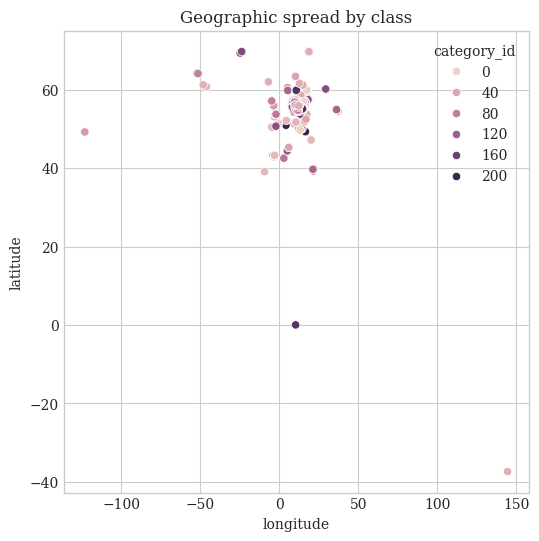

In [27]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='longitude', y='latitude', data=data, hue='category_id')
plt.title("Geographic spread by class")
plt.show()

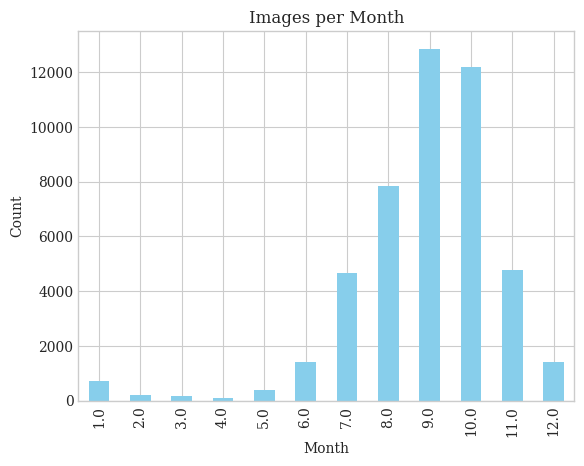

In [33]:
# count by month
counts_month = data['month'].value_counts().sort_index()
counts_month.plot(kind='bar', color='skyblue')
plt.title("Images per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()